<a href="https://colab.research.google.com/github/mfernandasoni/Exploring_Behavioral_Factors_NovaRetail-/blob/main/Project_NovaRetail_MFSC_ESP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`


La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` tiene un tipo de dato *float*, cuando lo más lógico es que sea tipo *int* para no tener edades a medias.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df["edad"]=df["edad"].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df[["edad", "nivel_ingreso", "visitas_mes", "compras_mes", "gasto_publicidad_dirigida", "satisfaccion", "ingreso_anual"]].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**

Diagnóstico inicial de variables numéricas

- `edad` — La media y la mediana son muy similares y su desviación estándar es pequeña, no se observa un sesgo significativo.
- `nivel_ingreso` - El nivel de ingreso anual estimado oscila entre 8000 y 74790, su desviación estándar es alta, significando alta dispersión de los datos.
- `visitas_mes` - La media y la mediana son muy similares, lo que significa que hay poca asimetría en los datos.
- `compras_mes` - La desviación estándar es muy baja. No hay mucha dispersión de los datos. Sin embargo observando la media y mediana, hay un sesgo a la derecha.
- `gasto_publicidad_dirigida` - El gasto en publicidad oscila entre 0 y 75, con una mediana de 19.73, no se observa un sesgo significativo.
- `satisfaccion` - La media y mediana son muy similares y la desviación estándar muy pequeña, se observa una simetría alta en los datos.
- `ingreso_anual` - La media se ve afectada por la dispersión de los datos, se observa un sesgo a la derecha.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
premium=df[["miembro_premium"]].value_counts()
abandono=df[["abandono"]].value_counts()
print(premium)
print()
print(abandono)

miembro_premium
0                  12911
1                   2089
dtype: int64

abandono
0           12739
1            2261
dtype: int64


✍️ **Comentario**
Diagnóstico inicial de variables binarias

- `miembro_premium` — Se observa que la mayoría de los usuarios no son miembros premium. Solo 2089 de 15,000 usuarios son miembros premium.
- `abandono` — Se observa que la mayoría de los usuarios no han abandonado la plataforma. Solo 2261 de 15000 usuarios han abandonado la plataforma.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df[["id_cliente", "tipo_dispositivo", "region"]].nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
tipo_disp=df[["tipo_dispositivo"]].value_counts()
region=df[["region"]].value_counts()
print(tipo_disp)
print()
print(region)

tipo_dispositivo
móvil               9818
escritorio          3720
tablet              1462
dtype: int64

region
norte     4395
oeste     3810
sur       3726
este      3069
dtype: int64


✍️ **Comentario**

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Se observa en la distribución que la mayor parte de los usuarios utilizan la plataforma en su dispositivo móvil, seguido de computadora de escritorio y finalmente en una tablet.
- `region`— La distribución de esta variable muestra que la mayor parte de los usuarios son del norte, después del oeste, seguido por sur y finalmente este.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

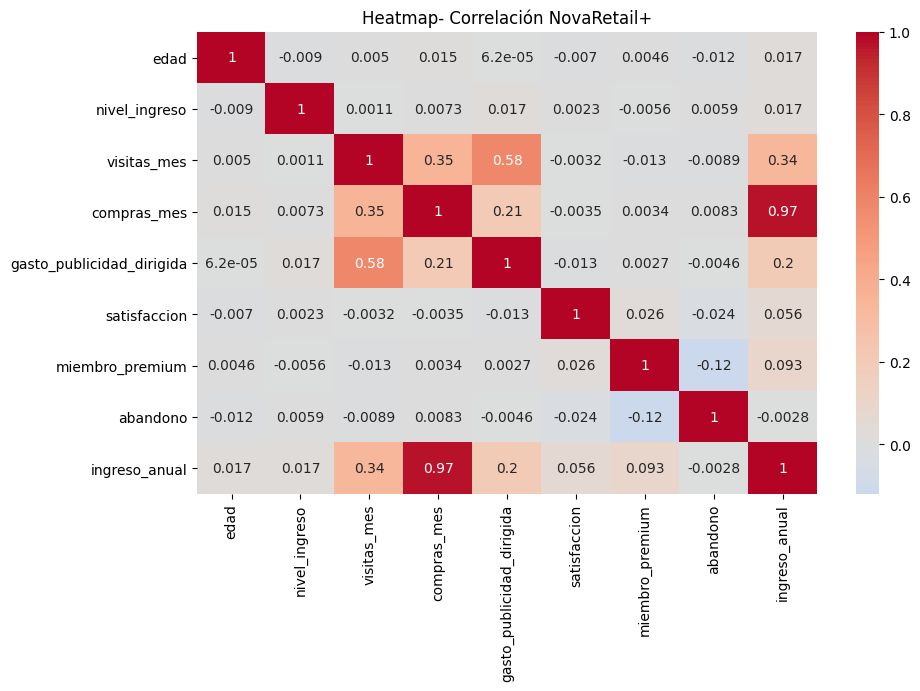

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr= df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap- Correlación NovaRetail+")
plt.show()


✍️ **Comentario**

Observaciones generales (Heatmap)  
- Se observa que la correlación positiva más fuerte es de `compras_mes` con `ingreso_anual`(0.97). Se tienen correlaciones positivas moderadas de `visitas_mes` con `gasto_publicidad_dirigida` (0.58),  `visitas_mes` con `compras_mes` (0.35) y `visitas_mes` con  `ingreso_anual` (0.34). Se tienen correlaciones positivas bajas de 0.21 y 0.2. La correlación negativa relevante observada es de `miembro_premium` con `abandono`(-0.12). Las variables `edad`, `nivel_ingreso` y `satisfaccion` presentan valores cercanos a cero con todas las demás variables, por lo que se consideran irrelevantes para el análisis.


Observaciones respecto a `ingreso_anual`  
- Presenta relación principalmente con 3 variables. Veamos cada una de ellas:
  1.
`visita_mes` y `ingreso_anual` demuestra una relación positiva moder (0.34).
  2. `compras_mes` y `ingreso_anual`
 demuestra una relación positiva muy alta (0.97). Sugiere que el volumen de compras mensual está fuertemente asociado al nivel de ingreso.
  3. `gasto_publicidad_dirigida` y `ingreso_anual` demuestra una relación positiva baja (0.2).


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

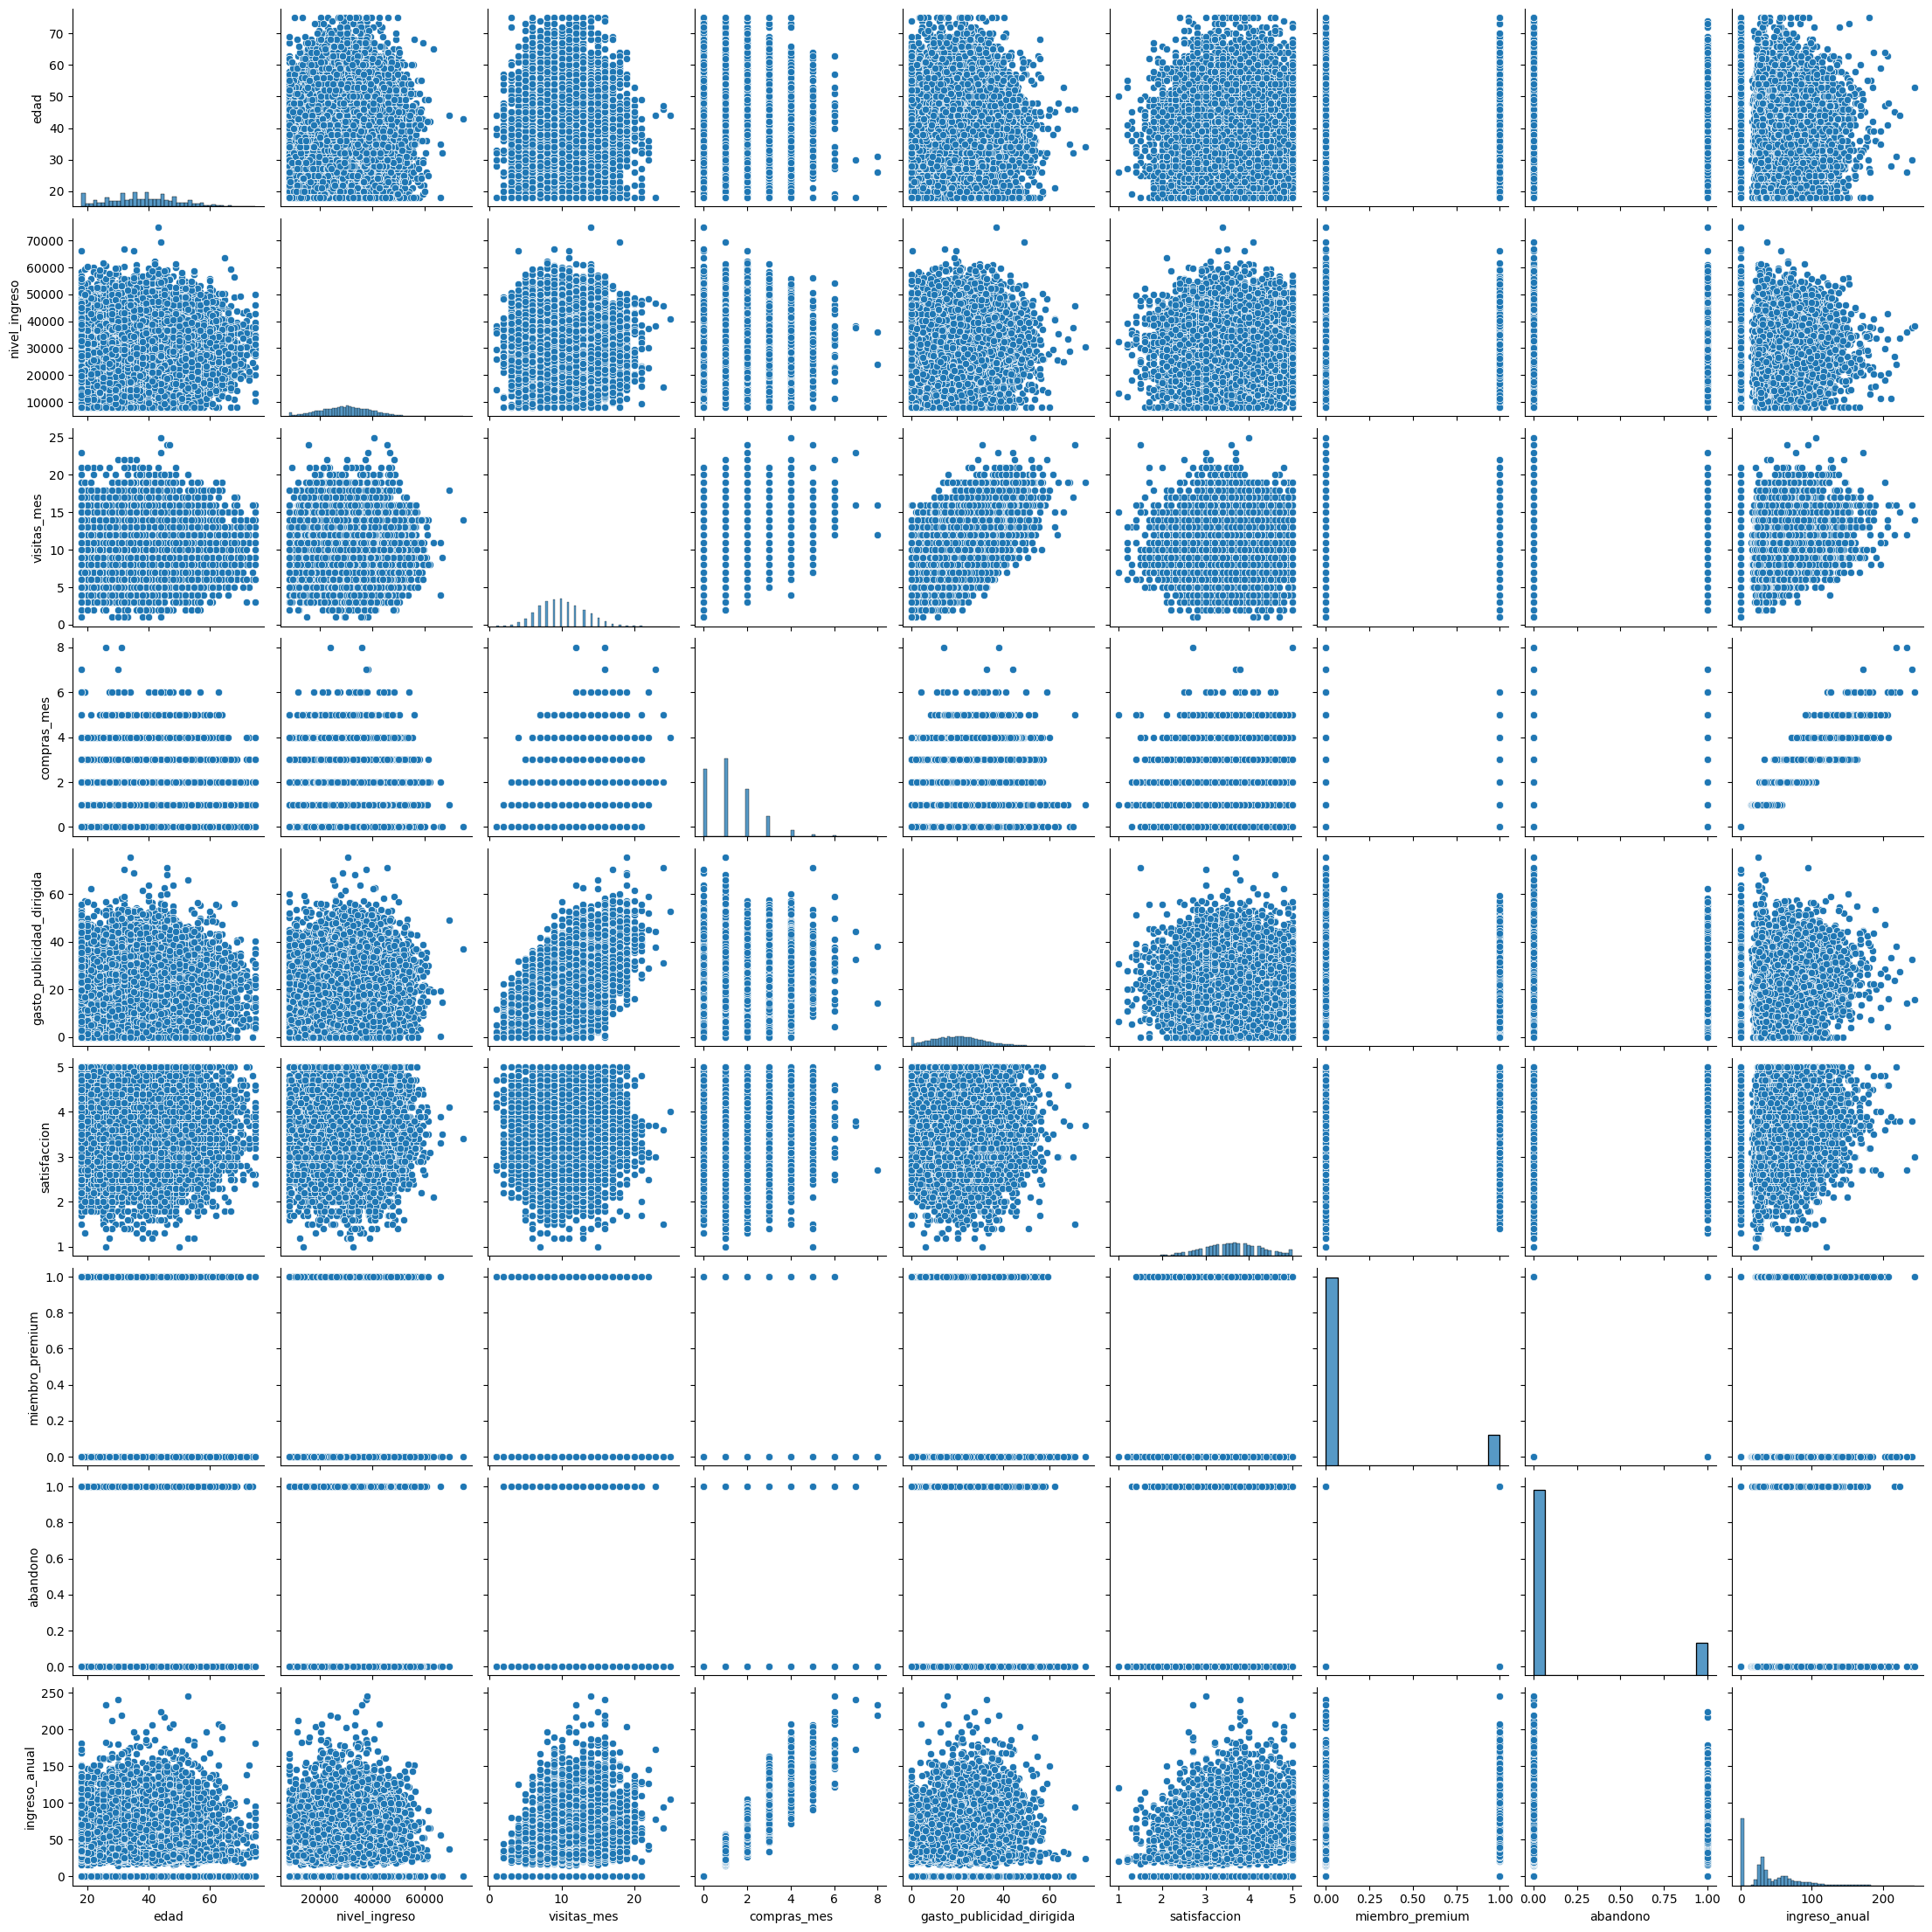

In [ ]:
sns.pairplot(df)

✍️ **Comentario**: En esta ocasión se realizó el scatterplot general, sin embargo no es necesario por 3 razones:

✅1: Con la cantidad de variables del dataset, el pairplot se vuelve difícil de leer e interpretar.

✅2: El heatmap ya permitió identificar los pares clave, por lo que el scatterplot general no agrega valor nuevo.

✅3: Se harán scatterplots por pares clave para el análisis.

### Scatterplot para pares clave

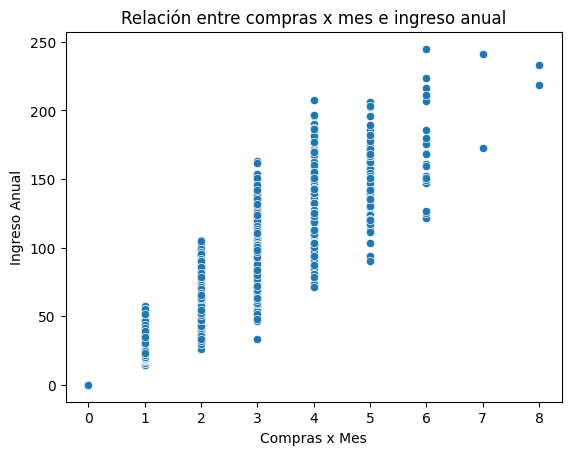

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

sns.scatterplot(
    data=df,
    x="compras_mes",
    y="ingreso_anual"
)

plt.title("Relación entre compras x mes e ingreso anual")
plt.xlabel("Compras x Mes")
plt.ylabel("Ingreso Anual")
plt.show()


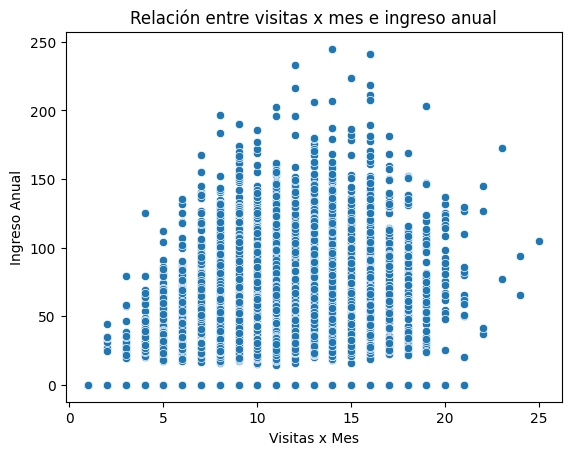

In [ ]:
sns.scatterplot(
    data=df,
    x="visitas_mes",
    y="ingreso_anual"
)

plt.title("Relación entre visitas x mes e ingreso anual")
plt.xlabel("Visitas x Mes")
plt.ylabel("Ingreso Anual")
plt.show()


✍️ **Comentario**


Observaciones iniciales (Scatterplot)

**ingreso_anual vs compras_mes**
- Dirección positiva
- Dispersión baja
- Se observan algunos puntos aislados en los niveles altos de compras_mes (6, 7 y 8) con valores de ingreso_anual notablemente superiores al resto de su grupo — visibles en la parte superior derecha del scatterplot. No son extremos graves, pero sí se separan del patrón central.
- Colinealidad: alta. La correlación de 0.97 son señales claras de colinealidad entre ambas variables.

**ingreso_anual vs visitas_mes**
- Dirección positiva
- Dispersión alta. La nube de puntos es amplia y difusa, sin una estructura definida.
- Outliers: Sí, moderada. Se observan puntos aislados con valores de ingreso_anual muy elevados (por encima de 200) distribuidos a lo largo de distintos niveles de visitas_mes, sin concentrarse en un rango específico.
- Colinealidad: Baja. Con una correlación de 0.34 y dispersión alta, estas dos variables no representan un riesgo de colinealidad relevante.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
corr_pearson= df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
print(f"Correlacion entre: compras_mes e ingreso_anual")
print(f"Pearson: {corr_pearson:.3f}")

Correlacion entre: compras_mes e ingreso_anual
Pearson: 0.967


In [ ]:
# Calcular correlación entre variables relevantes
corr_spearman= df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')
print(f"Correlacion entre: visitas_mes e ingreso_anual")
print(f"Spearman: {corr_spearman:.3f}")

Correlacion entre: visitas_mes e ingreso_anual
Spearman: 0.321


✍️ **Comentario**
Observaciones de correlación

**compras_mes vs ingreso_anual**
- Correlación positiva con magnitud alta de 0.967. A medida que aumenta compras_mes, ingreso_anual también crece de forma consistente.
- Alta colinealidad, su relación es casi perfecta.

**visitas_mes vs ingreso_anual**
- Correlación positiva con magnitud media de 0.321. Se aprecia una ligera tendencia a que valores más altos de visitas_mes se asocien con mayores valores de ingreso_anual.
- Baja colinealidad.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # Ignorar FutureWarning
from scipy.stats import pointbiserialr

pb,_ = pointbiserialr(df["ingreso_anual"],df["miembro_premium"])
print("Correlación entre: ingreso_anual y miembro_premium")
print(f"Punto-biserial: {pb:.3f}")
print()
pb2,_ = pointbiserialr(df["ingreso_anual"],df["abandono"])
print("Correlación entre: ingreso_anual y abandono")
print(f"Punto-biserial: {pb2:.3f}")

Correlación entre: ingreso_anual y miembro_premium
Punto-biserial: 0.093

Correlación entre: ingreso_anual y abandono
Punto-biserial: -0.003


✍️ **Comentario**

Observaciones Punto-biserial

**ingreso_anual y miembro_premium**
- Relación positiva casi nula. Sugiere que el ingreso_anual se relaciona muy ligeramente con el ser miembro_premium o no.

**ingreso_anual y abandono**
- Relación negativa casi nula. Sugiere que el ingreso_anual casi no se relaciona con los usuarios segun su status de suscripción (abandono o activo).

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    return v

In [ ]:
# Aplicar V de Cramér en variables relevantes
coef_cramer= cramer_v(df, "region", "tipo_dispositivo")
print("Correlación entre: region y tipo_dispositivo")
print(f"V de Cramer: {coef_cramer:.3f}")

Correlación entre: region y tipo_dispositivo
V de Cramer: 0.012


✍️ **Comentario**
Observaciones V de Cramér

Se observa que region no tiene una asociación con tipo_dispositivo. Su relación es muy débil.  


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio


### Hallazgo 1 — `ingreso_anual` y `compras_mes`
**Evidencia visual:** heatmap y scatterplot  
**Evidencia numérica:** Pearson ≈ 0.97

**Interpretación**  
Los clientes que realizan más compras mensuales generan significativamente más ingreso a la empresa.

**No podemos afirmar**  
Que incrementar artificialmente las compras garantice proporcionalmente más ingreso, ni descartar que ambas variables estén calculadas a partir de una misma fuente.

**Implicación de negocio**  
`compras_mes` es prácticamente un indicador directo del ingreso que un cliente genera. Estrategias orientadas a aumentar la frecuencia de compra tendrían impacto directo y medible en el ingreso empresarial.

### Hallazgo 2 — `ingreso_anual` y `visitas_mes`

**Evidencia visual:** Heatmap y scatterplot
**Evidencia numérica:** Spearman ≈ 0.32

**Interpretación**  
Los clientes que visitan más la plataforma tienden a generar ligeramente más ingreso a la empresa, aunque la relación es débil. Muchas visitas no necesariamente se traducen en mayor valor económico.

**No podemos afirmar**  
Que aumentar visitas cause directamente más ingreso para la empresa.

**Implicación de negocio**  
Las visitas son una señal de engagement, pero no suficiente por sí sola. Convendría analizar la calidad de la visita — no solo su frecuencia — para entender qué convierte visitas en ingreso real.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Variables no medidas (producto comprado, canal de adquisición del cliente, antigüedad)
- `compras_mes`  como posible variable derivada. La correlación de 0.97 con ingreso_anual sugiere que ambas podrían calcularse a partir de la misma fuente, lo que limitaría su valor como variables independientes en un modelo.
- Variables categóricas con asociación nula. `region` y `tipo_dispositivo` no muestran relación entre sí (V de Cramér = 0.012), pero tampoco se analizó su relación individual con el ingreso o el abandono.
- Sesgo en `ingreso_anual`. La distribución sesgada a la derecha puede afectar la estabilidad de los coeficientes de correlación de Pearson y reducir la representatividad de los análisis en los segmentos de mayor valor.

### **Próximos pasos**

Probar segmentación adicional
- Dividir la base en segmentos por valor de ingreso generado (alto, medio, bajo)
- Analizar comportamiento de abandono según perfil de visitas_mes, satisfaccion y miembro_premium

Validar relaciones mediante experimentos
- Diseñar pruebas A/B para evaluar si incrementar visitas o frecuencia de compra impacta el ingreso real

Ampliar el análisis exploratorio
- Explorar relaciones no lineales en variables como `satisfaccion` y `edad` con métodos alternativos.
